# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

Use `pandas`, `numpy`, `seaborn`, `matplotlib`, and `scikit-learn`. Do **not** use scikit-learn pipelines for this assignment. Use ordinary data frames, `pd.get_dummies`, and `LinearRegression` so that every column in the model is visible and interpretable.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Check that `brand_share` sums to 1 within each year.
3. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
4. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
5. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [278]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# load data
df = pd.read_csv('air_fryers_clean_brand_year.csv')
print(f"Shape of the dataset: {df.shape}")

# important cols
cols = [
    'year',
    'brand',
    'purchase_count',
    'product_count',
    'avg_price',
    'avg_rating',
    'brand_share',
    'log_brand_share',
    'compact_share',
    'dual_basket_share',
    'oven_style_share',
    'rotisserie_share',
    'window_share'
]

# subset data for important features
df_analysis = df[cols].copy()
print(f"Subsetted dataset shape: {df_analysis.shape}")
df_analysis.head()



Shape of the dataset: (50, 15)
Subsetted dataset shape: (50, 13)


,year,brand,purchase_count,product_count,avg_price,avg_rating,brand_share,log_brand_share,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
0,2019,chefman,1146,10,72.963695,4.434119,0.076015,-2.576826,1.000000,0.0,0.780977,0.243455,0.184119
1,2019,cosori,11,2,159.990000,4.581818,0.000730,-7.222964,1.000000,0.0,0.090909,0.090909,0.000000
2,2019,cuisinart,1616,22,229.465274,4.481312,0.107190,-2.233150,0.993812,0.0,0.889851,0.000000,0.000000
3,2019,dash,3011,19,55.176333,4.390767,0.199721,-1.610832,1.000000,0.0,0.973431,0.000000,0.000000
4,2019,gowise usa,4405,45,83.575551,4.552259,0.292186,-1.230364,0.999773,0.0,0.129398,0.128490,0.000000


In [279]:
# check column datatypes
print("Column datatypes:")
print(df_analysis.dtypes)

# check for missing values
print("\nMissing values in each column:")
print(df_analysis.isnull().sum())

Column datatypes:
year                   int64
brand                 object
purchase_count         int64
product_count          int64
avg_price            float64
avg_rating           float64
brand_share          float64
log_brand_share      float64
compact_share        float64
dual_basket_share    float64
oven_style_share     float64
rotisserie_share     float64
window_share         float64
dtype: object

Missing values in each column:
year                 0
brand                0
purchase_count       0
product_count        0
avg_price            0
avg_rating           0
brand_share          0
log_brand_share      0
compact_share        0
dual_basket_share    0
oven_style_share     0
rotisserie_share     0
window_share         0
dtype: int64


### Missing values and data cleanup: 
- We have no missing values and no need to do any further data cleanup.


In [280]:
# verify brand has 10 brands and year has 2019-23
print(f"Number of unique brands: {df_analysis['brand'].nunique()}")
print("The brands are:")
print(df_analysis['brand'].unique())

print(f"\nNumber of unique years: {df_analysis['year'].nunique()}")
print("The years are:")
print(df_analysis['year'].unique())

Number of unique brands: 10
The brands are:
['chefman' 'cosori' 'cuisinart' 'dash' 'gowise usa' 'instant_pot' 'ninja'
 'nuwave' 'oster' 'ultrean']

Number of unique years: 5
The years are:
[2019 2020 2021 2022 2023]


#### The data contains 10 brands and all years

In [281]:
# check brand_shares add up to 1
df_analysis.groupby('year')['brand_share'].sum()


year
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
Name: brand_share, dtype: float64

#### brand_shares do sum to 1 for each year

The following code is to see if there is a correlation between rotisserie and window:

In [282]:
df_analysis[["rotisserie_share", "window_share"]].corr()

,rotisserie_share,window_share
rotisserie_share,1.00000,0.81603
window_share,0.81603,1.00000


Brands that offer more rotisserie air fryers also tend to offer more window-style air fryers. It is possible that rotisserie air fryers are also window style air fryers, however, we can't say that for sure. 

This was added more so to see the potential relationship.

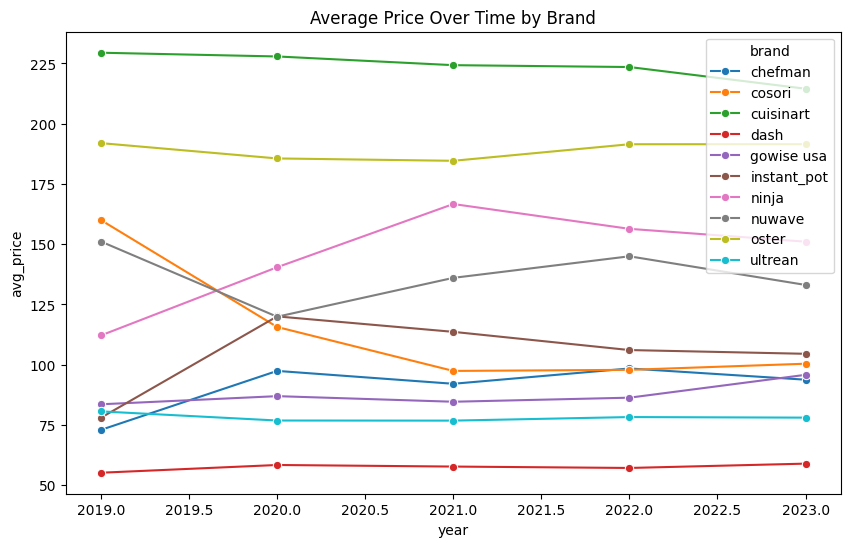

In [283]:
# Plot average price over time by brand
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_analysis,
    x="year",
    y="avg_price",
    hue="brand",
    marker="o"
)

plt.title("Average Price Over Time by Brand")
plt.show()

Cuisinart & Oster:
These two brands have consistently remained the most expensive options on the market. Cuisinart has been slowly lowering its price every year but still sits at the top, well above $210. Oster has stayed remarkably steady, hovering right around the $190 mark for nearly the entire five-year period.

Cosori:
Cosori shows the most dramatic pricing shift on the chart. They started as a premium brand at $160 in 2019 but aggressively cut their prices down to about $115 the following year. Since 2021, they have settled into a mid-range price of approximately $100.

Ninja & Nuwave: 
Both brands are more expensive today than they were when they started. Ninja saw a significant price spike in 2021, reaching nearly $170, before settling back down to around $150. Nuwave also followed an upward trend after 2020, moving from $120 to the $135–$145 range.

Instant Pot: 
Instant Pot had a massive price increase between 2019 and 2020, jumping from under $80 to $120. However, since that peak, they have been slowly and steadily lowering their price every year, ending 2023 at about $105.

Dash & Ultrean:
These brands have focused entirely on price stability for the budget shoppers. Dash has stayed almost perfectly flat at $55–$60 for five years straight. Ultrean is similarly consistent, staying locked in at the $75–$80 price point since 2019.

Chefman & GoWISE USA:
Both brands saw their prices rise slightly early on but have since leveled out. They now compete closely in the $85–$95 range, showing very little price movement over the last three years.

#### identifying expensive brands

In [284]:
df_analysis.groupby('brand')['avg_price'].mean().sort_values(ascending=False)

brand
cuisinart      223.947093
oster          189.031284
ninja          145.342541
nuwave         137.024384
cosori         114.267950
instant_pot    104.461353
chefman         90.938411
gowise usa      87.454781
ultrean         78.114606
dash            57.478927
Name: avg_price, dtype: float64

Cuisinart and Oster lead the premium market with the highest average prices, followed by Ninja and Nuwave in the mid-to-high tier. Chefman, Instant Pot, Cosori, and GoWISE USA occupy the mid-range, while Ultrean and Dash remain the most affordable budget options.

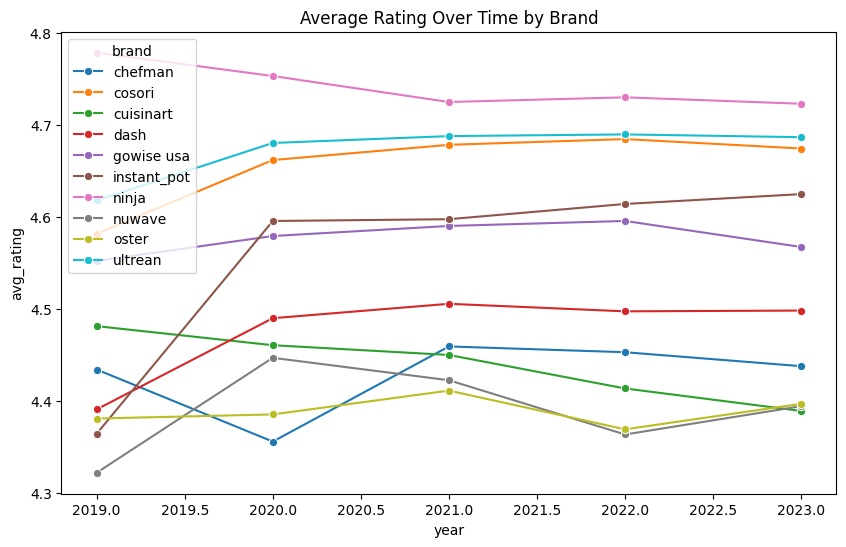

In [285]:
# plot average rating over time by brand
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_analysis,
    x="year",
    y="avg_rating",
    hue="brand",
    marker="o"
)

plt.title("Average Rating Over Time by Brand")
plt.show()

#### Interpretation/Findings
Ninja & Ultrean:
Ninja has maintained the highest overall satisfaction since 2019. While it saw a very slight dip early on, it has remained the most consistent top-tier brand. Ultrean also showed strong early growth and has stayed remarkably steady at a high rating for the last three years.

Instant Pot & Cosori:
These brands saw the most "bounce" in their early years. Instant Pot started with some of the lowest scores on the chart but made a massive leap in 2020 and has been rising slowly ever since. Cosori followed a similar trend, showing a sharp increase in ratings through 2021 before leveling off.

Chefman & Nuwave:
These brands experienced the most volatility. Chefman saw its ratings drop significantly in 2020 before bouncing back, while Nuwave has gone through multiple ups and downs, including a notable dip in 2022. They represent the most unpredictable satisfaction levels on the chart.

Cuisinart:
In a market where most brands improved or stayed stable, Cuisinart is the outlier. It has experienced a slow but consistent decline in ratings every year since 2019, ending with a lower score than it started with.

Dash & Oster:
These brands have been the most consistent in the middle of the pack. Dash saw a small improvement in 2020 and has held that score almost perfectly ever since. Oster has stayed almost entirely flat, showing that customer perception of the brand hasn't changed much in five years.

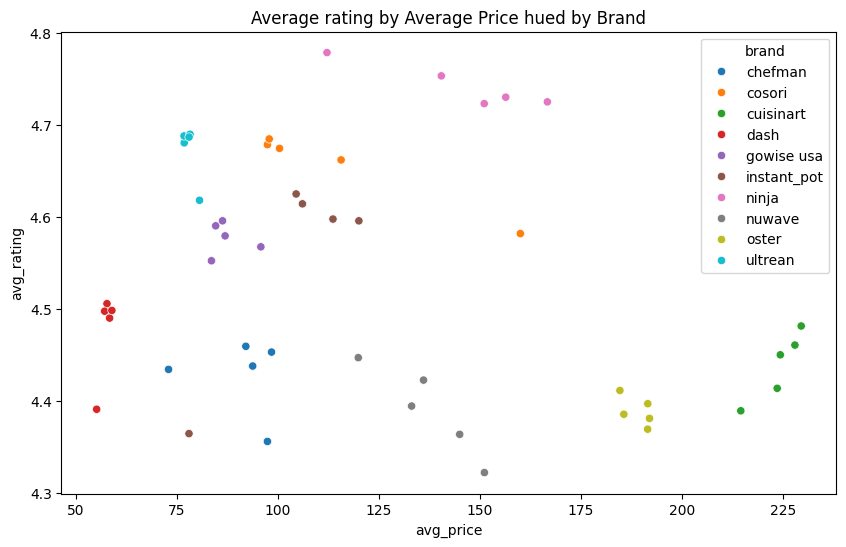

In [286]:
# rating by price hued by brand 

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_analysis,
    x="avg_price",
    y="avg_rating",
    hue="brand",
    marker="o"
)

plt.title("Average rating by Average Price hued by Brand")
plt.show()

#### Interpreation/findings
This graph shows the relationship between what a brand costs and how highly customers rate it. Can give insight to see what brand is best for quality and price.

Ninja: 
Ninja stands out with the highest overall ratings on the graph. Even though their products are on the more expensive side (mostly between $110 and $170), customers seem to feel the quality justifies the cost, as their ratings consistently hit the 4.7 to 4.8 range.

Ultrean: 
Ultrean is a major highlight for anyone looking for a deal. They managed to achieve very high customer satisfaction (around 4.6 to 4.7) while keeping their prices quite low, mostly under $85. They offer similar quality to the top brands but at a much lower price point.

Cuisinart & Oster: 
These two brands represent the most expensive options on the chart, with Cuisinart reaching prices over $225. However, a higher price didn't lead to better reviews here. Both brands actually have lower ratings (around 4.4) than many of the cheaper brands, suggesting that a luxury price tag doesn't always mean a better experience.

Dash: 
Dash is the most affordable brand shown, with prices sitting around $55 to $60. While they don't have the "best" ratings on the board, they maintain a solid 4.5, making them a reliable and predictable choice for people who want the lowest possible price.

Cosori, Chefman & GoWISE USA: 
These brands sit in the middle of the pack. Cosori performs well with high ratings for a moderate price, while Chefman and GoWISE offer decent quality for those who don't want to spend more than $100. Nuwave tends to struggle in this group, with lower ratings despite being more expensive than some of its direct competitors.

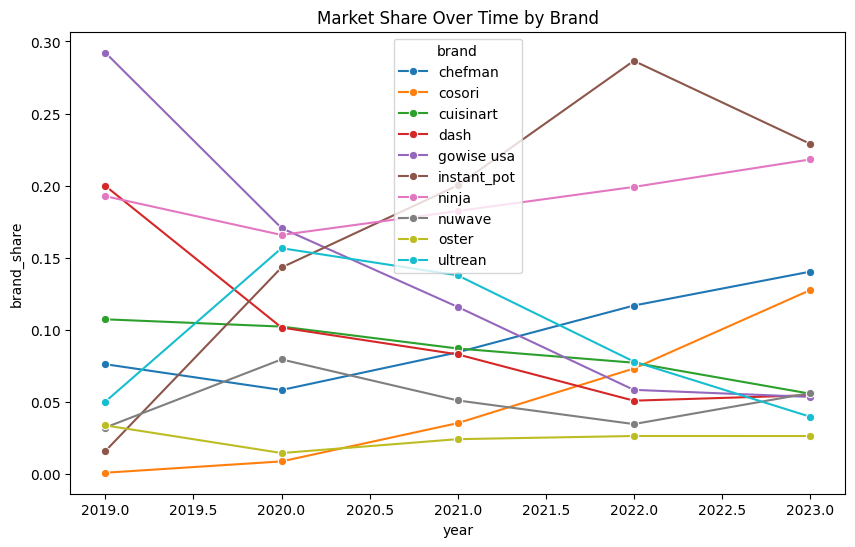

In [287]:
# plot brand market share over time by brand
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_analysis,
    x="year",
    y="brand_share",
    hue="brand",
    marker="o"
)

plt.title("Market Share Over Time by Brand")
plt.show()

#### Interpretation/findings

Between 2019 and 2023, the market underwent a massive shift, characterized by the displacement and rise of certain brands

Instant Pot
The most dramatic performer, rising from a negligible share (under 0.025) in 2019 to a market-leading peak of ~0.29 in 2022. Despite a slight correction to ~0.23 in 2023, it remains the dominant brand.

Ninja
Demonstrated resilient growth. After a brief dip in 2020 (~0.17), it steadily climbed to ~0.22 by 2023, surpassing its 2019 baseline and securing the second-largest market share.

Cosori & Chefman
Both brands saw impressive upward trajectories. Notably, Cosori grew from nearly 0% share in 2019 to ~0.13 in 2023, while Chefman nearly doubled its footprint, ending the period at ~0.14.

GoWISE USA
Experienced the most precipitous drop, falling from the market leader position in 2019 (~0.29) to just ~0.05 in 2023.

Dash
Followed a similar downward trend, losing roughly 75% of its 2019 share as it fell from ~0.20 to <0.05.

Ultrean
Showed high volatility; it spiked significantly between 2019 and 2021 before crashing back to ~0.04 by 2023—leaving it slightly below its starting position.

Cuisinart, Oster & Nuwave
Cuisinart maintained a slow but consistent decline throughout the five-year period. Meanwhile, Oster and Nuwave remained largely stagnant, ending 2023 without any meaningful change in their market positioning.

#### how common features are

Average share of features across all brands and years:
compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64


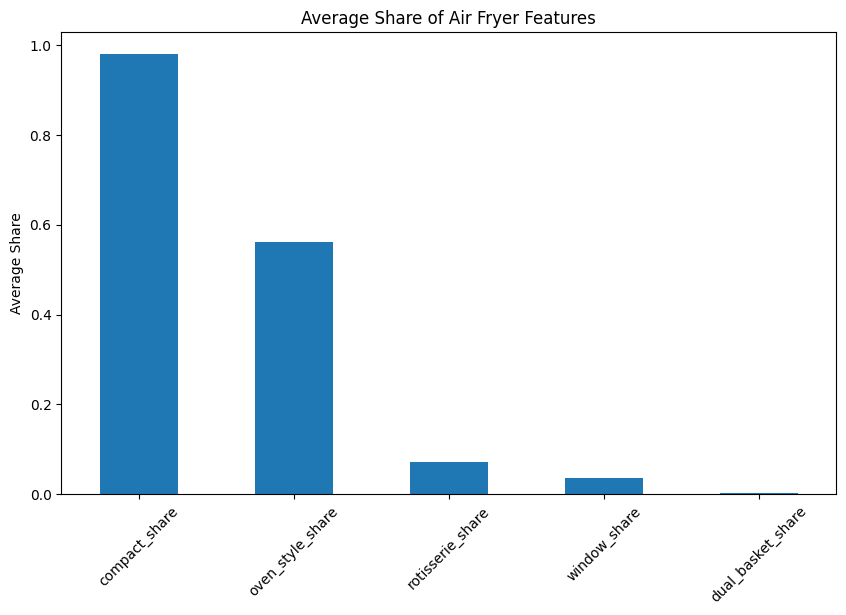

In [288]:
# checking which features are most common

feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]
common_features = df_analysis[feature_cols].mean().sort_values(ascending=False)
print("Average share of features across all brands and years:")
print(common_features)
common_features.plot(kind='bar', figsize=(10,6))
plt.title("Average Share of Air Fryer Features")
plt.ylabel("Average Share")
plt.xticks(rotation=45)
plt.show()


Across all brands and years compact airfryers are the most common product type (.98), followed by oven style models (.56). 

Features like rotisserie, windowed, and dual basket airfryers are relatively rare, with dual basket airfryers being significantly rare according to the data.

#### Checking whether certain brands have more emphasis on a specific style

In [289]:
# checking if brands focus on styles more than others
df_analysis.groupby('brand')[feature_cols].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


### This is across all brands and years

#### Compact:
across brands and years, all brands in the dataset strongly emphasize compact air fryers, with compact shares generally above 96% for most brands. Instant Pot has the lowest share at about 86%, which is still high in absolute terms but indicates a relatively more diverse product lineup compared to competitors. Only Oster and Ultrean have a compact share of 100%, meaning all of their models in the dataset are classified as compact. Overall, nearly all brands show a dominant focus on compact designs across their products

#### Dual basket:
Across all brands and years, dual-basket air fryers are extremely rare. Only a few brands—Chefman, Ninja, NuWave, and Instant Pot—have any presence in this category, and even then, the share is very small. Chefman has the highest dual-basket share at about 1.35%, meaning it is the most likely among these brands to offer dual-basket models. However, even for Chefman, this feature represents only a tiny fraction of its product lineup. Instant Pot’s share (~0.003%) is effectively negligible, indicating almost no focus on dual-basket designs.

#### Oven style:
Across brands and years, oven-style air fryers are most prominent for Cuisinart (~91%), Dash (~89%), Oster (~86%), and Ultrean (~83%). Chefman (~60%) Nuwave (~54%) and Instant Pot (~67%) show moderate adoption, while others like Cosori (~2%) and Ninja (~10%) place relatively little emphasis on this style.

#### Rotisserie Share:
Across brands and years, rotisserie air fryers are generally uncommon. Most companies have rotisserie shares below 3%, and several brands show no rotisserie models at all. Chefman has the highest presence at about 37%, while GoWISE USA (~18%) and Instant Pot (~10%) show modest adoption. However, for major brands like Instant Pot and Ninja, rotisserie remains a minor feature within their broader product lines, suggesting it is not a central design focus even for leading players in the category.

#### Window share:
Across brands and years, window-equipped air fryers are relatively uncommon and unevenly distributed. Most brands show little to no emphasis on this feature, with many recording near-zero shares. Chefman and Instant Pot show the highest adoption at roughly 36% and 0.3% respectively, though even for these brands, window models represent a minority of their overall product lines. GoWISE USA (~0.1%) shows minimal presence, while several brands, including Cosori, Cuisinart, Dash, and Oster, show essentially no window-featured models. Overall, the data suggests that viewing windows are a niche feature rather than a standard design choice across the category.

#### Write-up for data analyst

The air fryer market is heavily defined by a standardized focus on compact designs, which accounts for almost all of the products across all brands, though oven-style models maintain a notable secondary presence at 56%. While Cuisinart and Oster consistently command the highest average prices as premium players, they have struggled to capture significant market share compared to Instant Pot and Ninja, which currently lead the industry with shares of ~23% and ~22% respectively. The market has proven highly unstable over the last five years, characterized by the collapse of early leaders like GoWISE USA and the rapid rise of Cosori, which grew from near-zero presence to a major mid-range competitor. While most brands stick to basic compact builds, Chefman differentiates itself by offering the highest adoption of niche features like rotisserie (37%) and viewing windows (36%). Chefman seems to be the most diverse in terms of incorporating various features in their product (they are also the same brand who experienced a collapse in market share over time. It'd be interesting to see if their collapse is due to trying to accomodate these niche features and to see if their customer base didn't actually like/want that) Ultimately, the data shows a volatile landscape where high-priced legacy brands are being squeezed by more consistent, high-performing newcomers.

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the typical unit costs and markups?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs?
4. Which brands have the highest average markups?
5. Which brands have the highest share-weighted average profit?
6. Make kernel density plots of unit costs, markups, and average profit.
7. Make scatter plots of price vs. unit cost and average rating vs. unit cost.

Finally, compute:

$$
\frac{d\pi_{bt}}{dp_{bt}} = \hat{s}'_{bt}(p_{bt})(p_{bt} - \hat{c}_{bt}) + s_{bt}.
$$

This should be very close to zero **by construction**, because you used the same first-order condition to estimate unit cost. Treat this as a numerical check, not as independent evidence that prices are truly optimal.

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability.

## 4. Results

Submit a GitHub repo containing:

1. A short presentation of your findings, about 5-8 slides.
2. The code that created the tables and figures in your presentation.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion: which brands look strongest, and what would you want to investigate next?

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.